In [21]:
import pandas as pd
import ast

from collections import Counter, defaultdict
import math
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import re


In [4]:
data = joblib.load('OTHERresample.pkl')
x_train = data['X_train']
y_train = data['y_train']
x_test = data['X_test']
y_test = data['y_test']


In [8]:
train_df=pd.DataFrame({"text":x_train,"category_10":y_train})
test_df=pd.DataFrame({"text":x_test,"category_10":y_test})

In [10]:
train_df["text"]

59513                    scar people narrowly escaped death
94858         meet last pigeon keeper new york east village
74660     rebelling border one artist painting immigrati...
34622     neil gaiman dramatically read seuss raise mill...
58588         hulus handmaid tale add joseph fiennes banana
                                ...                        
54614     student said donald trump inspired hate crime ...
138797                                 secret simplify life
25625     steve bannon chris christie lack loyalty cost ...
27147          america founding father would outraged trump
204769    visiting manitoba adorable terrifying polar be...
Name: text, Length: 118492, dtype: object

In [22]:
def preprocess_headline(text):
    text = text.lower()
    text = re.sub(r"\d+", "<N>", text)
    text = re.sub(r"[^\w\s<>]", "", text)
    tokens = text.split()
    return tokens

In [ ]:
train_df["tokens"] = train_df["text"].apply(preprocess_headline)
test_df["tokens"]  = test_df["text"].apply(preprocess_headline)

In [24]:
train_df

,text,category_10,tokens
59513,scar people narrowly escaped death,OTHER,"[scar, people, narrowly, escaped, death]"
94858,meet last pigeon keeper new york east village,OTHER,"[meet, last, pigeon, keeper, new, york, east, ..."
74660,rebelling border one artist painting immigrati...,OTHER,"[rebelling, border, one, artist, painting, imm..."
34622,neil gaiman dramatically read seuss raise mill...,OTHER,"[neil, gaiman, dramatically, read, seuss, rais..."
58588,hulus handmaid tale add joseph fiennes banana,OTHER,"[hulus, handmaid, tale, add, joseph, fiennes, ..."
...,...,...,...
54614,student said donald trump inspired hate crime ...,POLITICS,"[student, said, donald, trump, inspired, hate,..."
138797,secret simplify life,WELLNESS,"[secret, simplify, life]"
25625,steve bannon chris christie lack loyalty cost ...,POLITICS,"[steve, bannon, chris, christie, lack, loyalty..."
27147,america founding father would outraged trump,POLITICS,"[america, founding, father, would, outraged, t..."


# Building N-grams

In [ ]:
def build_word_model_with_padding(sentences, n=3):

    model = defaultdict(Counter)

    for sentence in sentences:
        words = [word.lower() for word in sentence]
        padded = ["<s>"] * (n - 1) + words + ["</s>"]

        for i in range(len(padded) - (n - 1)):
            prefix = tuple(padded[i : i + n - 1])
            next_word = padded[i + n - 1]
            model[prefix][next_word] += 1

    return model


In [31]:
def build_ngram_models_per_category(train_df, n=2):
    ngram_models = {}

    categories = train_df["category_10"].unique()

    for category in categories:
        sentences = train_df[train_df["category_10"] == category]["tokens"].tolist()
        model = build_word_model_with_padding(sentences, n=n)

        vocab = set()
        total_ngrams = 0
        for prefix, counter in model.items():
            for word, count in counter.items():
                vocab.add(word)
                total_ngrams += count

        ngram_models[category] = {
            "ngram_counts": model,
            "total_ngrams": total_ngrams,
            "vocab": vocab,
            "vocab_size": len(vocab),
            "n": n
        }

    return ngram_models


In [32]:
unigram_models = build_ngram_models_per_category(train_df, n=1)
bigram_models = build_ngram_models_per_category(train_df, n=2)
trigram_models = build_ngram_models_per_category(train_df, n=3)

# calculate the probability

In [ ]:
def ngram_probability(prefix, word, model):
    ngram_counts = model["ngram_counts"]
    v_size = model["vocab_size"]

    prefix_counts = ngram_counts.get(prefix, Counter())
    x=prefix_counts.get(word, 0) + 1
    y=sum(prefix_counts.values()) + v_size

    return x/y


In [ ]:
def ngram_log_likelihood(tokens, model):
    n=model["n"]
    padded=["<s>"]*(n-1)+tokens+["</s>"]
    log_prob =0.0

    for i in range(len(padded)-(n-1)):
        prefix =tuple(padded[i:i+n-1])#marko
        word =padded[i+n-1]

        prob= ngram_probability(prefix,word,model)
        log_prob+= math.log(prob)

    return log_prob


In [ ]:
def ngram_perplexity(tokens, model):
    N=len(tokens) + 1

    log_prob=ngram_log_likelihood(tokens, model)

    return math.exp(-log_prob / N)


In [19]:
def classify_with_perplexity(tokens, ngram_models):
    scores = {}

    for category, model in ngram_models.items():
        scores[category] = ngram_perplexity(tokens, model)

    return min(scores, key=scores.get)


In [38]:
def classify_with_likelihood_and_perplexity(tokens, ngram_models):
    results = {}

    for category, model in ngram_models.items():
        likelihood = ngram_log_likelihood(tokens, model)
        perplexity = ngram_perplexity(tokens, model)

        results[category] = {
            "log_likelihood": likelihood,
            "perplexity": perplexity
        }

    return results


In [ ]:
def predict_by_perplexity(results):
    return min(results, key=lambda x: results[x]["perplexity"])
def predict_by_likelihood(results):
    return max(results, key=lambda x: results[x]["log_likelihood"])


# Scoring results

In [ ]:
y_true = test_df["category_10"].tolist()

In [54]:
y_pred = []

for tokens in test_df["tokens"]:
    pred = classify_with_perplexity(tokens, unigram_models)
    y_pred.append(pred)

accuracy = accuracy_score(y_true, y_pred)
print(f"unigram LM (Perplexity) Accuracy: {accuracy:.4f}")


unigram LM (Perplexity) Accuracy: 0.4894


In [ ]:
y_pred_perplexity = []
y_pred_likelihood = []

for tokens in test_df["tokens"]:
    res = classify_with_likelihood_and_perplexity(tokens, unigram_models)
    y_pred_perplexity.append(predict_by_perplexity(res))
    y_pred_likelihood.append(predict_by_likelihood(res))



acc_perplexity = accuracy_score(y_true, y_pred_perplexity)
acc_likelihood = accuracy_score(y_true, y_pred_likelihood)
print(f"Unigram LM Accuracy (Perplexity): {acc_perplexity:.4f}")
print(f"Unigram LM Accuracy (Log-Likelihood): {acc_likelihood:.4f}")


Unigram LM Accuracy (Perplexity): 0.4894
Unigram LM Accuracy (Log-Likelihood): 0.4894


In [52]:
y_pred = []

for tokens in test_df["tokens"]:
    pred = classify_with_perplexity(tokens, bigram_models)
    y_pred.append(pred)

accuracy = accuracy_score(y_true, y_pred)
print(f"Bigram LM (Perplexity) Accuracy: {accuracy:.4f}")


Bigram LM (Perplexity) Accuracy: 0.3164


In [51]:
y_pred_perplexity = []
y_pred_likelihood = []

for tokens in test_df["tokens"]:
    res = classify_with_likelihood_and_perplexity(tokens, bigram_models)
    y_pred_perplexity.append(predict_by_perplexity(res))
    y_pred_likelihood.append(predict_by_likelihood(res))



acc_perplexity = accuracy_score(y_true, y_pred_perplexity)
acc_likelihood = accuracy_score(y_true, y_pred_likelihood)
print(f"bigram LM Accuracy (Perplexity): {acc_perplexity:.4f}")
print(f"bigram LM Accuracy (Log-Likelihood): {acc_likelihood:.4f}")


bigram LM Accuracy (Perplexity): 0.3164
bigram LM Accuracy (Log-Likelihood): 0.3164


In [46]:
y_pred = []

for tokens in test_df["tokens"]:
    pred = classify_with_perplexity(tokens, trigram_models)
    y_pred.append(pred)

accuracy = accuracy_score(y_true, y_pred)
print(f"trigram LM (Perplexity) Accuracy: {accuracy:.4f}")


trigram LM (Perplexity) Accuracy: 0.1649


In [48]:
y_pred_perplexity = []
y_pred_likelihood = []

for tokens in test_df["tokens"]:
    res = classify_with_likelihood_and_perplexity(tokens, trigram_models)
    y_pred_perplexity.append(predict_by_perplexity(res))
    y_pred_likelihood.append(predict_by_likelihood(res))



acc_perplexity = accuracy_score(y_true, y_pred_perplexity)
acc_likelihood = accuracy_score(y_true, y_pred_likelihood)
print(f"trigram LM Accuracy (Perplexity): {acc_perplexity:.4f}")
print(f"trigram LM Accuracy (Log-Likelihood): {acc_likelihood:.4f}")


trigram LM Accuracy (Perplexity): 0.1649
trigram LM Accuracy (Log-Likelihood): 0.1649


In [55]:
categories = list(bigram_models.keys())

cm = confusion_matrix(y_true, y_pred, labels=categories)
cm_df = pd.DataFrame(cm, index=categories, columns=categories)

cm_df


,OTHER,WELLNESS,FOOD & DRINK,POLITICS,TRAVEL,QUEER VOICES,STYLE & BEAUTY,BUSINESS,ENTERTAINMENT,SPORTS
OTHER,3649,2252,1659,1667,1275,2337,1065,2535,1239,1351
WELLNESS,71,2488,272,41,133,129,37,279,40,99
FOOD & DRINK,6,27,1114,2,50,13,8,27,5,16
POLITICS,269,107,90,5162,111,342,31,669,93,246
TRAVEL,30,34,113,13,1601,36,28,75,11,39
QUEER VOICES,22,33,25,38,14,1025,15,29,36,32
STYLE & BEAUTY,21,54,95,9,42,39,1594,69,20,19
BUSINESS,21,67,48,68,50,38,12,839,15,40
ENTERTAINMENT,64,59,76,109,89,309,235,161,2163,208
SPORTS,10,14,11,12,13,26,8,26,21,874


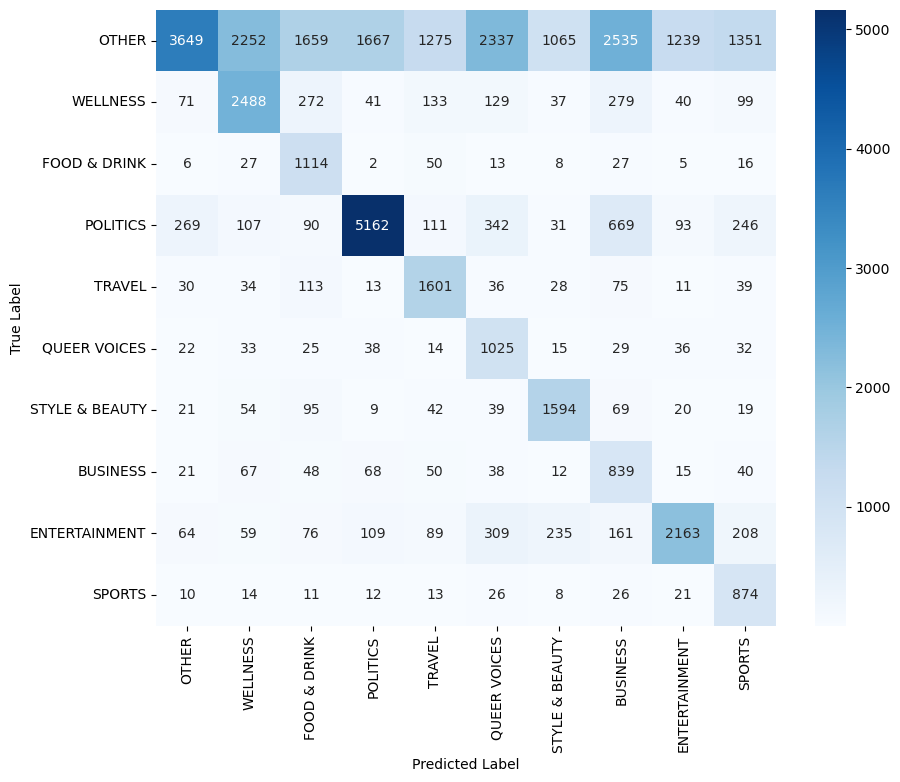

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()
plt.savefig("Unigram_OTHER_confusion_matrix.png", dpi=300)
plt.close()
